In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.table import Table
import pandas as pd

In [12]:
# --- 1. Load the catalog ---
cat = pd.read_csv('/home/thsu/FRB_population/chimefrbcat2.csv')

# Apply quality cuts
mask = (
    (cat['excluded_flag'] == 0) &
    (cat['citizen_science_flag'] == 0) &
    (cat['sidelobe_flag'] == 0) &
    (cat['sub_num'] == 0) &
    (cat['bonsai_snr'] >= 10) &
    ((cat['repeater_name'].isna()) | (cat['repeater_name'] == ''))  # non-repeaters
)
cat_filtered = cat[mask]

# Extract columns
peak_freq = cat_filtered['peak_freq']
dm = cat_filtered['dm_fitb']
snr = cat_filtered['snr_fitb']
flux = cat_filtered['flux']


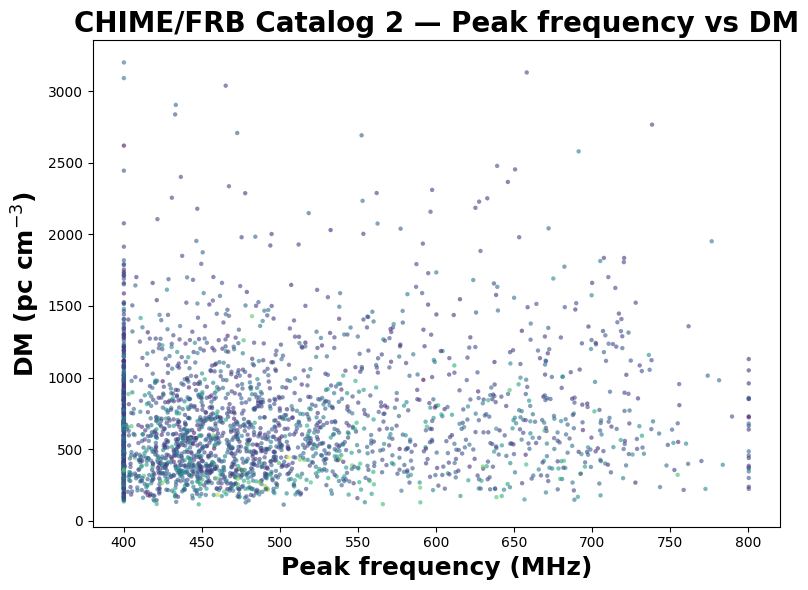

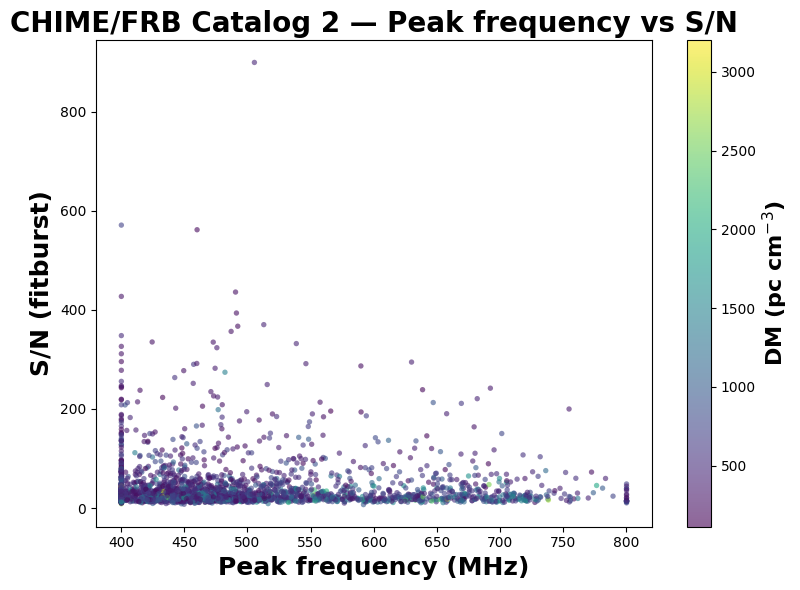

In [16]:
# --- 3a. Peak frequency vs DM (colored by S/N) ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    peak_freq,    # swapped: now x-axis
    dm,           # swapped: now y-axis
    c=np.log10(snr),   # colour by log(S/N)
    cmap='viridis', s=10, alpha=0.6, linewidths=0
)
ax.set_xlabel('Peak frequency (MHz)', fontweight='bold', fontsize = 18)
ax.set_ylabel(r'DM (pc cm$^{-3}$)', fontweight='bold', fontsize = 18)
ax.set_title('CHIME/FRB Catalog 2 — Peak frequency vs DM', fontweight='bold', fontsize = 20    )
plt.tight_layout()
plt.savefig('peak_freq_vs_dm.pdf', dpi=150)
plt.show()

# --- 3b. Peak frequency vs S/N (colored by DM) ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    peak_freq,    # swapped: now x-axis
    snr,          # swapped: now y-axis
    c=dm,             # colour by DM
    cmap='viridis', s=15, alpha=0.6, linewidths=0,
    norm=mcolors.Normalize(vmin=dm.min(), vmax=dm.max()) 
)
cb = fig.colorbar(sc, ax=ax, label=r'DM (pc cm$^{-3}$)')
cb.set_label(r'DM (pc cm$^{-3}$)', size=16, weight="bold")
ax.set_xlabel('Peak frequency (MHz)', fontweight='bold', fontsize = 18)
ax.set_ylabel('S/N (fitburst)', fontweight='bold', fontsize = 18)
ax.set_title('CHIME/FRB Catalog 2 — Peak frequency vs S/N', fontweight='bold', fontsize = 20    )
# ax.set_yscale('log')
plt.tight_layout()
plt.savefig('peak_freq_vs_snr.pdf', dpi=150)
plt.show()

Total FRBs in 400–800 MHz: 2354
400–500 MHz: 1570 / 2354 = 0.667
700–800 MHz: 91 / 2354 = 0.039


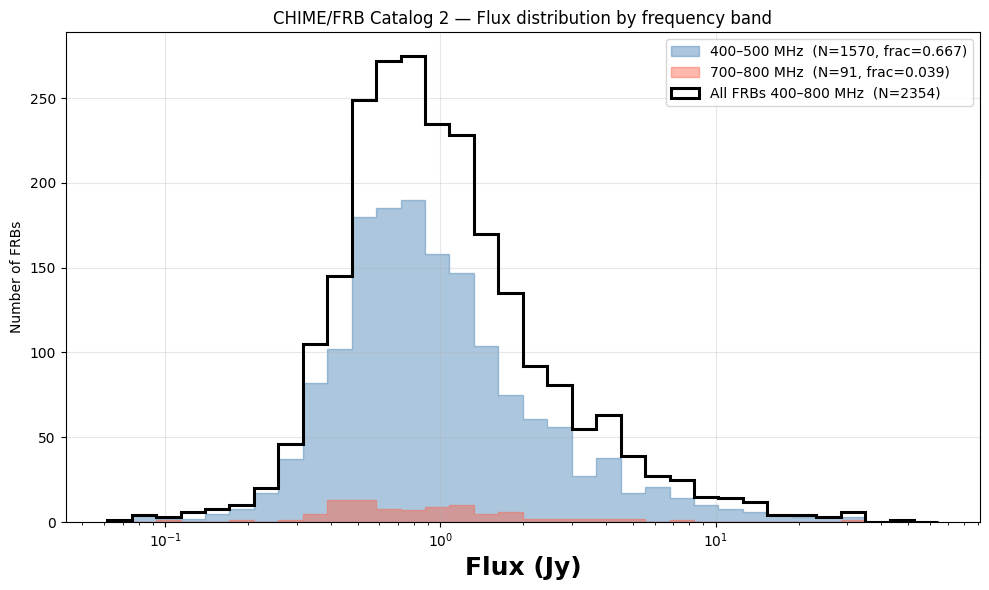

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure these are numpy arrays
peak_freq = np.asarray(peak_freq)
flux = np.asarray(flux)

# Keep only finite, positive flux values
valid = np.isfinite(peak_freq) & np.isfinite(flux) & (flux > 0)
peak_freq = peak_freq[valid]
flux = flux[valid]

# Frequency masks
mask_400_500 = (peak_freq >= 400) & (peak_freq < 500)
mask_700_800 = (peak_freq >= 700) & (peak_freq < 800)
mask_400_800 = (peak_freq >= 400) & (peak_freq < 800)

# Counts for fraction report
n_400_500 = np.sum(mask_400_500)
n_700_800 = np.sum(mask_700_800)
n_400_800 = np.sum(mask_400_800)

frac_400_500 = n_400_500 / n_400_800 if n_400_800 > 0 else 0.0
frac_700_800 = n_700_800 / n_400_800 if n_400_800 > 0 else 0.0

print(f"Total FRBs in 400–800 MHz: {n_400_800}")
print(f"400–500 MHz: {n_400_500} / {n_400_800} = {frac_400_500:.3f}")
print(f"700–800 MHz: {n_700_800} / {n_400_800} = {frac_700_800:.3f}")

# Flux bins
bins = np.logspace(np.log10(flux.min()), np.log10(flux.max()), 35)

# Histograms
flux_400_500 = flux[mask_400_500]
flux_700_800 = flux[mask_700_800]
flux_400_800 = flux[mask_400_800]

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    flux_400_500,
    bins=bins,
    histtype='stepfilled',
    alpha=0.45,
    color='steelblue',
    edgecolor='steelblue',
    label=f'400–500 MHz  (N={n_400_500}, frac={frac_400_500:.3f})'
)

ax.hist(
    flux_700_800,
    bins=bins,
    histtype='stepfilled',
    alpha=0.45,
    color='tomato',
    edgecolor='tomato',
    label=f'700–800 MHz  (N={n_700_800}, frac={frac_700_800:.3f})'
)

# Reference: all FRBs in 400–800 MHz
ax.hist(
    flux_400_800,
    bins=bins,
    histtype='step',
    linewidth=2.2,
    color='black',
    label=f'All FRBs 400–800 MHz  (N={n_400_800})'
)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Flux (Jy)', fontweight='bold', fontsize = 18)
ax.set_ylabel('Number of FRBs')
ax.set_title('CHIME/FRB Catalog 2 — Flux distribution by frequency band')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

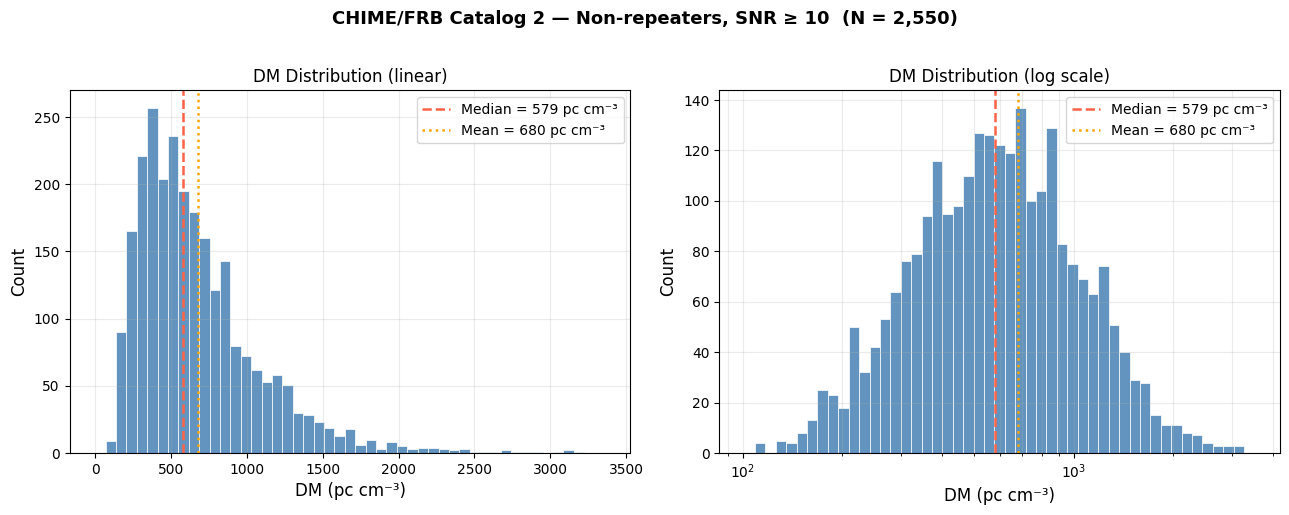


DM summary (pc cm⁻³)
  N       : 2,550
  Min     : 112.5
  Max     : 3200.1
  Mean    : 679.5
  Median  : 579.0
  Std     : 414.4
  16th pct: 320.7
  84th pct: 1040.3


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load and filter the catalog ---
cat = pd.read_csv('/home/thsu/FRB_population/chimefrbcat2.csv')

mask = (
    (cat['excluded_flag'] == 0) &
    (cat['citizen_science_flag'] == 0) &
    (cat['sidelobe_flag'] == 0) &
    (cat['sub_num'] == 0) &
    (cat['bonsai_snr'] >= 10) &
    ((cat['repeater_name'].isna()) | (cat['repeater_name'] == ''))
)
cat_filtered = cat[mask]

dm = cat_filtered['dm_fitb'].dropna()

# --- 2. Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Left: linear scale --
ax = axes[0]
bins_lin = np.linspace(0, dm.max() * 1.05, 50)
ax.hist(dm, bins=bins_lin, color='steelblue', edgecolor='white',
        linewidth=0.6, alpha=0.85)
ax.axvline(dm.median(), color='tomato', linewidth=1.8, linestyle='--',
           label=f'Median = {dm.median():.0f} pc cm⁻³')
ax.axvline(dm.mean(), color='orange', linewidth=1.8, linestyle=':',
           label=f'Mean = {dm.mean():.0f} pc cm⁻³')
ax.set_xlabel('DM (pc cm⁻³)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('DM Distribution (linear)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)

# -- Right: log scale on x-axis --
ax = axes[1]
bins_log = np.logspace(np.log10(dm.min() * 0.9), np.log10(dm.max() * 1.1), 50)
ax.hist(dm, bins=bins_log, color='steelblue', edgecolor='white',
        linewidth=0.6, alpha=0.85)
ax.axvline(dm.median(), color='tomato', linewidth=1.8, linestyle='--',
           label=f'Median = {dm.median():.0f} pc cm⁻³')
ax.axvline(dm.mean(), color='orange', linewidth=1.8, linestyle=':',
           label=f'Mean = {dm.mean():.0f} pc cm⁻³')
ax.set_xscale('log')
ax.set_xlabel('DM (pc cm⁻³)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('DM Distribution (log scale)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.25)

fig.suptitle(
    f'CHIME/FRB Catalog 2 — Non-repeaters, SNR ≥ 10  (N = {len(dm):,})',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/dm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. Summary stats ---
print(f"\nDM summary (pc cm⁻³)")
print(f"  N       : {len(dm):,}")
print(f"  Min     : {dm.min():.1f}")
print(f"  Max     : {dm.max():.1f}")
print(f"  Mean    : {dm.mean():.1f}")
print(f"  Median  : {dm.median():.1f}")
print(f"  Std     : {dm.std():.1f}")
print(f"  16th pct: {np.percentile(dm, 16):.1f}")
print(f"  84th pct: {np.percentile(dm, 84):.1f}")